# Unit 4: 时频分析方法与应用

## 理论知识

### 4.1 为什么需要时频分析？

**ERP的局限性：**
- ERP只能捕获与事件时间锁定（time-locked）且相位一致（phase-locked）的信号
- 大量神经活动是时间相关但非相位锁定的（induced activity）
- 这些非相位锁定活动在ERP平均过程中被抵消

**时频分析的优势：**
- 同时揭示信号在时间和频率两个维度的变化
- 可以捕获相位锁定（evoked）和非相位锁定（induced）的神经振荡
- 提供对脑网络动态的更全面理解

### 4.2 神经振荡与频段

| 频段 | 频率范围 | 功能关联 |
|------|----------|----------|
| Delta | 0.5-4 Hz | 慢波睡眠、决策 |
| Theta | 4-8 Hz | 记忆编码、认知控制 |
| Alpha | 8-13 Hz | 抑制性处理、感觉门控 |
| Beta | 13-30 Hz | 运动控制、感觉整合 |
| Gamma | 30-100 Hz | 特征绑定、注意 |

### 4.3 时频分解方法

**短时傅里叶变换（STFT）：**
- 使用滑动窗口对信号进行局部傅里叶分析
- 权衡：窗口越长，频率分辨率越高，时间分辨率越低
- 固定时间-频率分辨率

**Morlet小波变换（Wavelet Transform）：**
- 使用可变宽度的小波基函数
- 低频：宽窗口（高频率分辨率，低时间分辨率）
- 高频：窄窗口（低频率分辨率，高时间分辨率）
- 更适合EEG分析

**多锥度方法（Multitaper Method）：**
- 使用多个正交的锥度函数（Slepian序列）
- 减少频谱泄漏
- 提供最优的频谱估计

### 4.4 时频指标

**功率（Power）：**
- 信号在特定时频点的能量
- 计算：复数小波系数的模平方
- 反映该频率成分的强度

**相位（Phase）：**
- 信号在特定时频点的相位角
- 用于相位同步分析

**事件相关同步/去同步（ERS/ERD）：**
- ERS（Event-Related Synchronization）：功率增加
- ERD（Event-Related Desynchronization）：功率降低
- 计算公式：10 × log10(P_activity / P_baseline)
- 单位：dB（分贝）

**总功率分解：**
- 总功率（Total Power）= 相位锁定功率（Evoked Power）+ 非相位锁定功率（Induced Power）
- Evoked Power：先平均再计算功率（仅相位锁定成分）
- Induced Power：先计算每个trial的功率再平均（包含所有成分）

### 4.5 Morlet小波参数

**小波周期数（n_cycles）：**
- 控制小波的时间-频率权衡
- 值越大：频率分辨率越高，时间分辨率越低
- 推荐：随频率变化（低频用小值，高频用大值）
- 公式：n_cycles = frequency / bandwidth

**频率设置：**
- 线性间距：适用于窄频率范围
- 对数间距：适用于宽频率范围（推荐）

### 4.6 统计分析

**时频数据的统计挑战：**
- 多维度比较（时间×频率×通道）
- 严重的多重比较问题

**解决方案：**
- 聚类置换检验（Cluster-based Permutation Test）
- 在时频域上进行空间-时间-频率聚类

### 4.7 应用场景

**事件相关去同步（ERD）：**
- 运动准备：mu节律（8-13 Hz）和beta节律（13-30 Hz）降低
- 感觉处理：alpha节律降低

**事件相关同步（ERS）：**
- 记忆任务：theta节律（4-8 Hz）增加
- 感觉运动：gamma节律（30-100 Hz）增加
- 运动后：beta反弹（beta rebound）

## 实践代码

In [1]:
# 导入必要的库
import os
import mne
import numpy as np
import matplotlib.pyplot as plt
from mne.time_frequency import tfr_morlet, tfr_multitaper

# 设置MNE日志级别
mne.set_log_level('WARNING')

print("Unit 4: 时频分析方法与应用")
print("=" * 40)

Unit 4: 时频分析方法与应用


### 1. 加载数据并预处理

In [2]:
# 修改MNE配置，指向本地数据集目录
data_dir = os.path.abspath("../datasets")
os.makedirs(data_dir, exist_ok=True)
mne.set_config("MNE_DATA", data_dir)
mne.set_config("MNE_DATASETS_SAMPLE_PATH", data_dir)

# 加载数据
sample_data_folder = mne.datasets.sample.data_path()
raw_file = sample_data_folder / 'MEG' / 'sample' / 'sample_audvis_filt-0-40_raw.fif'
raw = mne.io.read_raw_fif(raw_file, preload=True)
raw = raw.pick_types(eeg=True, stim=True, eog=True)

# 滤波（时频分析需要保留更宽的频率范围）
raw.filter(l_freq=0.5, h_freq=None, verbose=False)

# 设置参考,数据集已经有平均参考投影器
# raw.set_eeg_reference(ref_channels='average', projection=True, verbose=False)

# 查找事件并创建epochs
events = mne.find_events(raw, stim_channel='STI 014', verbose=False)
event_dict = {'auditory': 1, 'visual': 3}  # 左耳、左眼

# 创建较长的epochs（时频分析需要更长的时间窗口）
epochs = mne.Epochs(raw, events, event_id=event_dict,
                    tmin=-1.0, tmax=1.5,
                    baseline=None,
                    reject=dict(eeg=150e-6),
                    preload=True, verbose=False)
print(f'epochs_data shape: {epochs.get_data().shape}')

# 仅使用部分epochs以加速计算
epochs = epochs['auditory'].copy() # 取左耳刺激的epochs

print(f"数据准备完成: {len(epochs)} trials")
print(f"时间窗口: [{epochs.tmin}, {epochs.tmax}] s")
print(f"采样率: {epochs.info['sfreq']} Hz")

epochs_data shape: (142, 69, 376)
数据准备完成: 71 trials
时间窗口: [-0.9989760657919393, 1.498464098687909] s
采样率: 150.15374755859375 Hz


### 2. 功率谱密度（PSD）分析

在时频分析之前，先了解信号的频谱特征

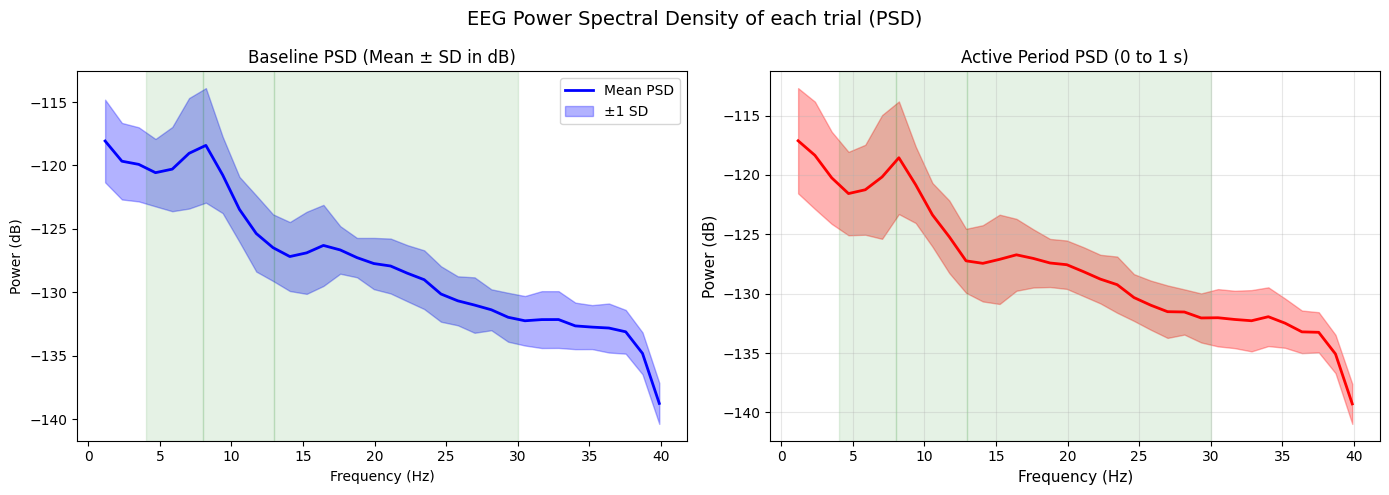

In [3]:
# 使用Welch方法计算PSD
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 基线期PSD（-1到0秒）
epochs_baseline = epochs.copy().crop(tmin=None, tmax=0.0)

spectrum_bl = epochs_baseline.compute_psd(
    method='welch',
    fmin=1,
    fmax=40,
    n_fft=128,
    verbose=False
)
# psds_bl shape:(71, 59, 34)
# freqs_bl shape: (34,)
psds_bl, freqs_bl = spectrum_bl.get_data(return_freqs=True)
# 先将所有数据转换为 dB (对数空间)
# 注意：这里是对完整的 psds_bl 进行转换，保持其原始维度 (n_epochs, n_channels, n_freqs)
psds_bl_db = 10 * np.log10(psds_bl)
mean_psd_bl_db = psds_bl_db.mean(axis=(0, 1))  # shape: (34,)
# 先对通道维度求平均
mean_ch_psd_bl_db = psds_bl_db.mean(axis=1)  # shape: (n_epochs,n_freqs)
# 再对epoch维度求标准差
std_psd_bl_db = mean_ch_psd_bl_db.std(axis=0)  # shape: (n_freqs,)

# 绘制均值曲线
axes[0].plot(freqs_bl, mean_psd_bl_db, color='blue', linewidth=2, label='Mean PSD')
axes[0].fill_between(freqs_bl, 
                     mean_psd_bl_db - std_psd_bl_db,  # 下界
                     mean_psd_bl_db + std_psd_bl_db,  # 上界
                     alpha=0.3, color='blue', label='±1 SD')

axes[0].set_xlabel('Frequency (Hz)')
axes[0].set_ylabel('Power (dB)')
axes[0].set_title('Baseline PSD (Mean ± SD in dB)')
axes[0].legend()


# 活动期PSD（0到1秒）
epochs_active = epochs.copy().crop(tmin=0.0, tmax=1.0)
spectrum_act = epochs_active.compute_psd(
    method='welch',
    fmin=1,
    fmax=40,
    n_fft=128,
    verbose=False
)
# psds_act shape:(71, 59, 34)
# freqs_act shape: (34,)
psds_act, freqs_act = spectrum_act.get_data(return_freqs=True)
psds_act_db = 10 * np.log10(psds_act)

mean_psd_act_db = psds_act_db.mean(axis=(0, 1))  # shape: (34,)
# 先对通道维度求平均
mean_ch_psd_act_db = psds_act_db.mean(axis=1)  # shape: (n_epochs,n_freqs)
# 再对epoch维度求标准差
std_psd_act_db = mean_ch_psd_act_db.std(axis=0)  # shape: (n_freqs,)

axes[1].plot(freqs_act, mean_psd_act_db, color='red', linewidth=2)
axes[1].fill_between(freqs_act,
                     mean_psd_act_db - std_psd_act_db,
                     mean_psd_act_db + std_psd_act_db,
                     alpha=0.3, color='red')
axes[1].set_xlabel('Frequency (Hz)', fontsize=11)
axes[1].set_ylabel('Power (dB)', fontsize=11)
axes[1].set_title('Active Period PSD (0 to 1 s)', fontsize=12)
axes[1].grid(True, alpha=0.3)

# 标注频段
for ax in axes:
    bands = {'Theta': (4, 8), 'Alpha': (8, 13), 'Beta': (13, 30)}
    for name, (fmin, fmax) in bands.items():
        ax.axvspan(fmin, fmax, alpha=0.1, color='green')
plt.suptitle('EEG Power Spectral Density of each trial (PSD)', fontsize=14)

plt.tight_layout()
plt.show()

### 3. Morlet小波时频分析

这个操作的核心目的是计算并保留每一次试验（trial）在不同频率上的能量（功率）随时间变化的情况。  
使用一组特定频率的Morlet小波作为“滤波器”，与每一段数据进行卷积运算，从而提取出信号在各个频率上的能量变化。  
freqs 和 n_cycles 这两个参数共同决定了时频分析的时间分辨率和频率分辨率，它们之间存在着一个根本性的权衡关系。  
freqs 定义了你想分析哪些频率，而 n_cycles 则决定了你用多长的“时间尺子”去测量这些频率。通过调整 n_cycles，你可以在时间和频率的精确度之间做出选择。

#### 3.1 计算单个trial的时频表示

In [9]:
# 定义频率范围和参数
freqs = np.arange(3, 40, 2)  # 3-40 Hz，步长2 Hz
n_cycles = freqs / 2.0  # 周期数随频率变化（低频2个周期，高频约20个周期）
# 时间窗口永远是0.5秒
print(n_cycles/freqs)


print(f"频率范围: {freqs[0]}-{freqs[-1]} Hz")
print(f"频率点数: {len(freqs)}")
print(f"小波周期数范围: {n_cycles[0]:.1f}-{n_cycles[-1]:.1f}")
print(f"\n正在计算Morlet小波时频变换...")
print("(这可能需要一些时间)")


[0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5
 0.5]
频率范围: 3-39 Hz
频率点数: 19
小波周期数范围: 1.5-19.5

正在计算Morlet小波时频变换...
(这可能需要一些时间)


In [ ]:
# 使用Morlet小波的时频表示
# use_fft=True: 使用FFT加速卷积
# average=False: 不平均，保留每个trial的数据
# return_itc=False: 不返回trial间相干性（ITC），节省内存
# Time-Frequency Representation using Morlet Wavelets
power = tfr_morlet(
    epochs,              # 输入的epochs数据
    freqs=freqs,         # 频率列表
    n_cycles=n_cycles,   # 每个频率的周期数
    use_fft=True,        # 使用FFT加速卷积
    return_itc=False,    # 不返回trial间相干性（ITC），节省内存
    average=False,       # 不平均，保留每个trial的数据
    verbose=False        # 不显示详细信息
) # shape: (trials, channels, nfreqs, times)

print(f"计算完成!")
print(f"时频数据形状: {power.data.shape}")
print(f"  - Trials: {power.data.shape[0]}")
print(f"  - Channels: {power.data.shape[1]}")
print(f"  - Frequencies: {power.data.shape[2]}")
print(f"  - Time points: {power.data.shape[3]}")

计算完成!
时频数据形状: (71, 59, 19, 376)
  - Trials: 71
  - Channels: 59
  - Frequencies: 19
  - Time points: 376


#### 3.2 基线校正与可视化
目的是消除信号中原本存在的背景噪声或个体差异，从而突显出由特定事件（如视觉刺激、运动任务）引起的“变化”。

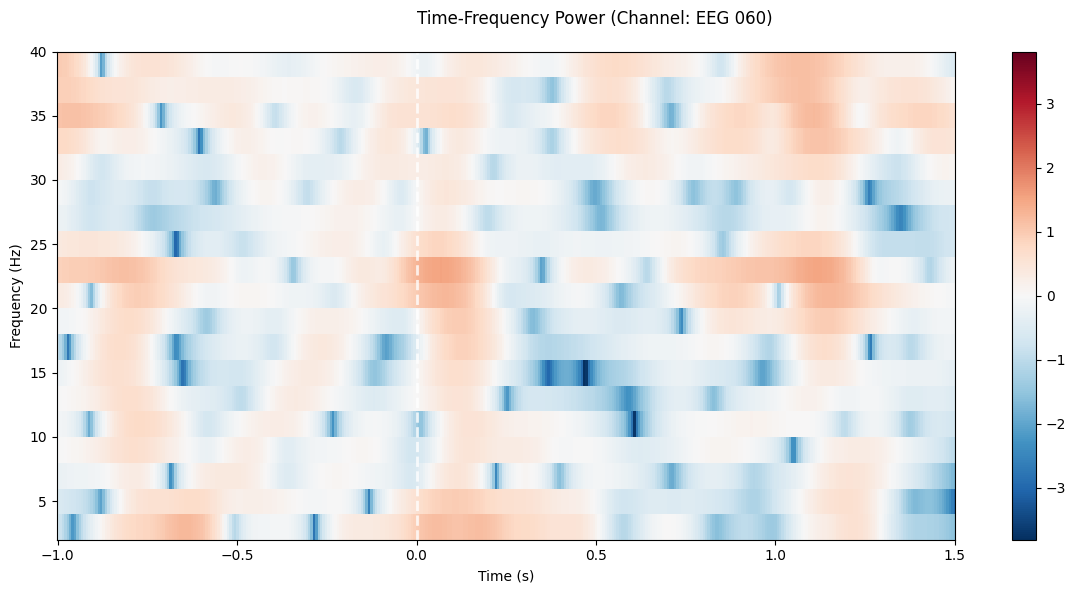

颜色说明:
  红色 = 功率增加（ERS）
  蓝色 = 功率降低（ERD）
  白色虚线 = 刺激开始


In [ ]:
# 转换为dB scale并进行基线校正
# baseline: 基线时间窗口
# mode: 基线校正方法
#   - 'logratio': 10 * log10(power / baseline)，常用
#   - 'ratio': power / baseline
#   - 'percent': (power - baseline) / baseline * 100
#   - 'zscore': (power - baseline) / baseline.std

power_db = power.copy() # shape(n_trials,n_channels, n_freqs, n_times)
# 应用基线校正，将功率值转换为相对于基线的对数比率
# baseline参数指定基线时间窗口为刺激前-0.5秒到-0.1秒
# mode='logratio'表示使用对数比率法：10 * log10(power / baseline_mean)
power_db.apply_baseline(
    baseline=(-0.5, -0.1), 
    mode='logratio'
)

# 选择感兴趣的通道
ch_idx = power.ch_names.index('EEG 060')

# 这里我们选择第 20 个 trial (索引从0开始),但是不会失去第一维
single_trial_power = power_db[20] 
# shape(1, n_channels, n_freqs, n_times)

# 绘制时频图
fig, ax = plt.subplots(figsize=(12, 6))

# 绘制单个通道的时频功率图
im = single_trial_power.plot(
    picks=[ch_idx],      # 只可视化感兴趣的通道->(n_freqs, n_times)
    show=False,          # 不立即显示图形，以便后续自定义
    axes=ax,             # 指定绘制的坐标轴对象
    cmap='RdBu_r',       # 使用红蓝反转色图：红色表示增加，蓝色表示降低
    colorbar=True,
    title=f'Time-Frequency Power (Channel: {power.ch_names[ch_idx]})'
)

# 添加事件触发线标注
ax.axvline(x=0, color='white', linestyle='--', linewidth=2, alpha=0.8)

plt.tight_layout()
plt.show()

print("颜色说明:")
print("  红色 = 功率增加（ERS）")
print("  蓝色 = 功率降低（ERD）")
print("  白色虚线 = 刺激开始")

#### 3.3 多通道时频图

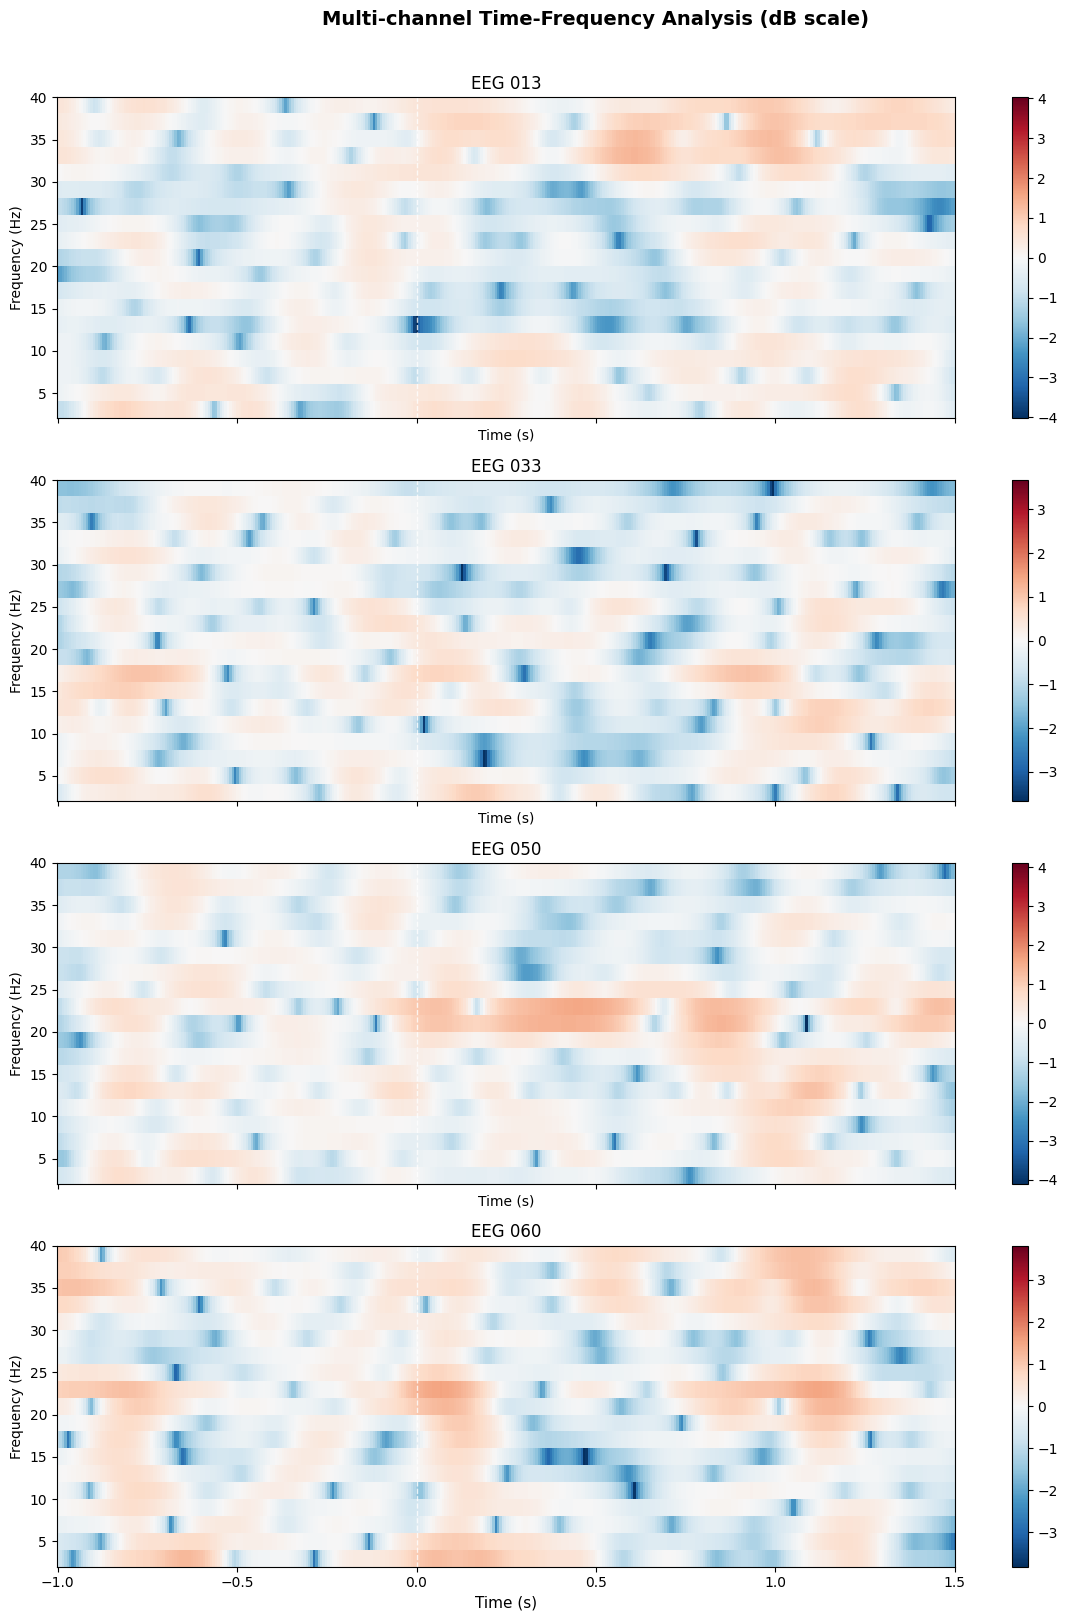

In [23]:
# 绘制多个通道的时频图
# 选择几个代表性通道
picks = ['EEG 013', 'EEG 033', 'EEG 050', 'EEG 060']

# 共享x轴和y轴
fig, axes = plt.subplots(len(picks), 1, figsize=(12, 16), sharex=True, sharey=True)

for i, ch_name in enumerate(picks):
    ch_idx = power.ch_names.index(ch_name)
    im = single_trial_power.plot(picks=[ch_idx], show=False, axes=axes[i], cmap='RdBu_r',
                       colorbar=True)
    axes[i].set_title(f'{ch_name}', fontsize=12)
    axes[i].axvline(x=0, color='white', linestyle='--', linewidth=1, alpha=0.8)

axes[-1].set_xlabel('Time (s)', fontsize=11)
plt.suptitle('Multi-channel Time-Frequency Analysis (dB scale)', 
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### 4. 平均时频表示

计算所有trial的平均时频功率

(59, 19, 376)
(59, 19, 376)


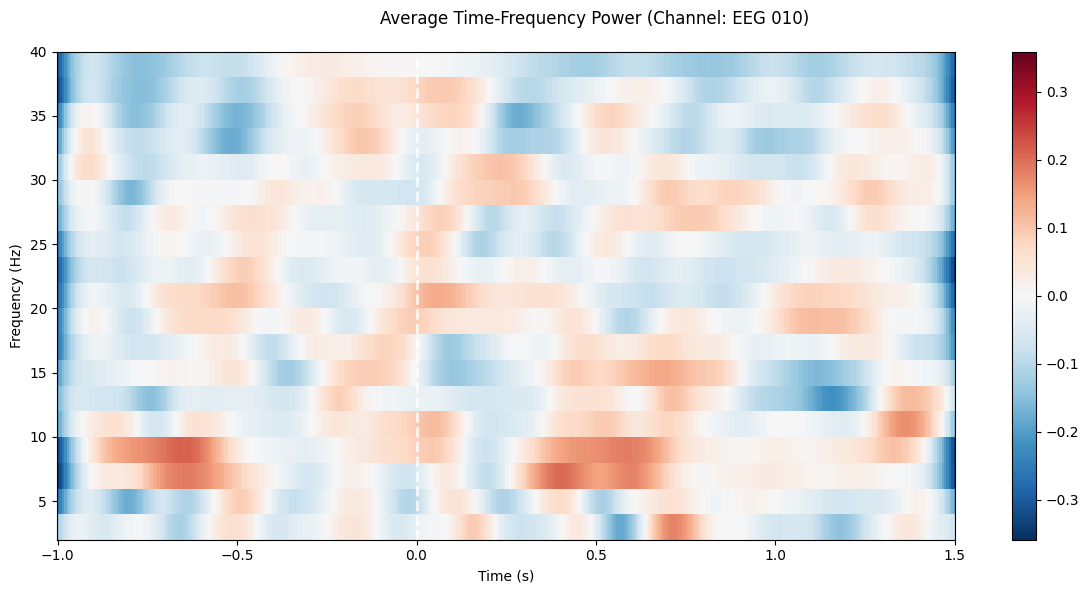

In [ ]:
# 计算平均时频功率
power_avg = power.average()  # 对第0个维度(trial)进行平均化 # (59,19,376)
# 应用基线校正，将功率值转换为相对于基线的对数比率
power_avg.apply_baseline(baseline=(-0.5, -0.1), mode='logratio')
ch_idx = power_avg.ch_names.index('EEG 010')

# 使用MNE的可视化方法
fig, ax = plt.subplots(figsize=(12, 6))
power_avg.plot(
    picks=[ch_idx], # (19,376)
    show=False,
    axes=ax,
    cmap='RdBu_r',
    colorbar=True,
    title=f'Average Time-Frequency Power (Channel: {power_avg.ch_names[ch_idx]})'
)
ax.axvline(x=0, color='white', linestyle='--', linewidth=2, alpha=0.8)
plt.tight_layout()
plt.show()


(19,)
(19,)


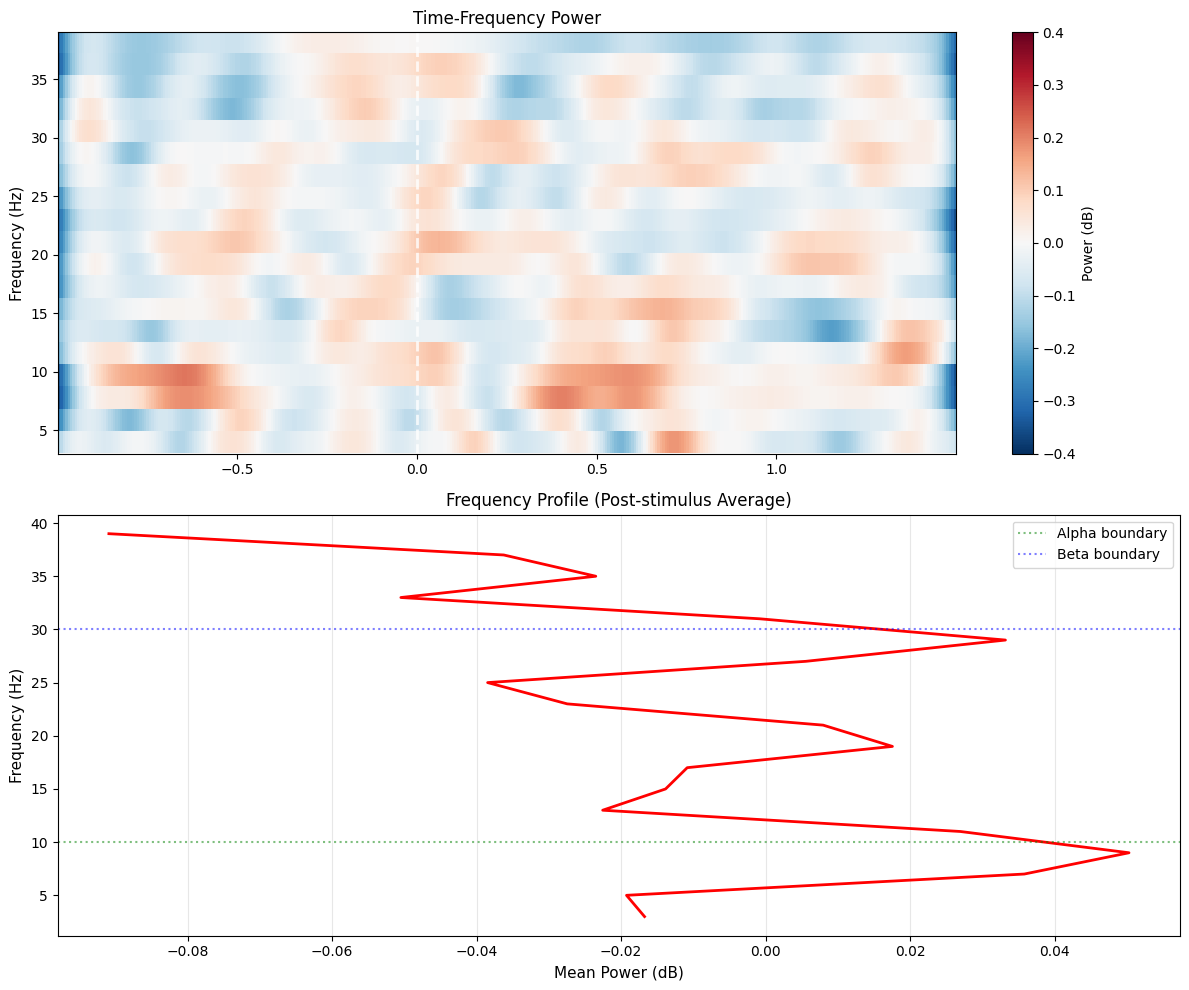

In [159]:
# 绘制频率边缘分布（时间平均）
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))
# 上图：完整时频图
# ax1.imshow() 默认会对图像进行插值,使图像更平滑,但会损失细节
# 可以通过设置interpolation='none'来禁用插值
im = ax1.imshow(
    power_avg.data[ch_idx],  # 只可视化感兴趣的通道  # (19, 376)(n_freqs, n_times)
    aspect='auto',           # 自动调整长宽比
    origin='lower',          # 原点位于左下角
    cmap='RdBu_r',           # 红蓝反转色图
    vmin=-0.4,               # 颜色映射最小值
    vmax=0.4,                # 颜色映射最大值
    extent=[                 # 图像范围 [xmin, xmax, ymin, ymax]
        power.times[0],      # 起始时间
        power.times[-1],     # 结束时间
        freqs[0],            # 最低频率
        freqs[-1]            # 最高频率
    ],
    interpolation='none'     # 禁用插值
)
ax1.axvline(x=0, color='white', linestyle='--', linewidth=2, alpha=0.8)
ax1.set_ylabel('Frequency (Hz)', fontsize=11)
ax1.set_title('Time-Frequency Power', fontsize=12)
plt.colorbar(im, ax=ax1, label='Power (dB)')

# 下图：频率边缘分布（刺激后的平均功率变化）
tmask = power.times >= 0   # 仅使用刺激后的时间
# 目的是回答这个问题：刺激发生后，哪个频段的能量变化最剧烈？
# 注：power_avg.data[ch_idx, :, tmask]会改变维度顺序,从(nfreqs, times)变更为(times, nfreqs)
freq_profile = np.mean(power_avg.data[ch_idx, :, tmask], axis=0) # 对(时间维度)进行平均化
print(freq_profile.shape) # (nfreqs,)
print(freqs.shape)
# 在激活后一段时间里，每种频率的平均能量
ax2.plot(freq_profile, freqs, color='red', linewidth=2)
ax2.axhline(y=10, color='green', linestyle=':', alpha=0.5, label='Alpha boundary')
ax2.axhline(y=30, color='blue', linestyle=':', alpha=0.5, label='Beta boundary')
ax2.set_xlabel('Mean Power (dB)', fontsize=11)
ax2.set_ylabel('Frequency (Hz)', fontsize=11)
ax2.set_title('Frequency Profile (Post-stimulus Average)', fontsize=12)
ax2.legend()
ax2.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

### 5. 特定频段的时程分析

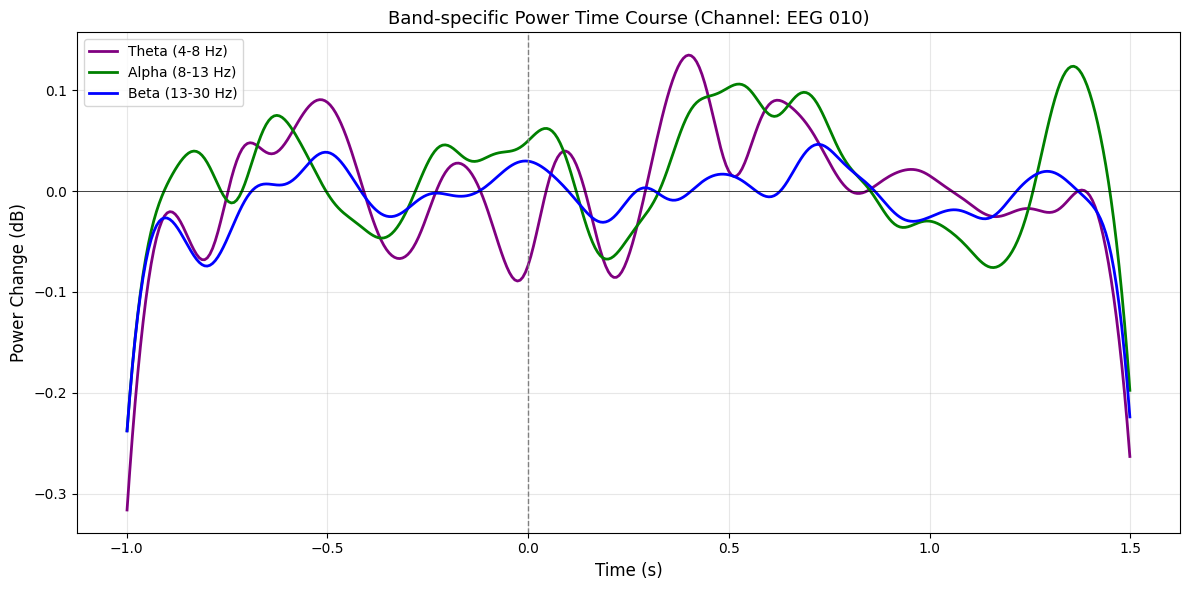

频段功率变化统计 (0-0.5s 窗口)

频段         平均变化(dB)        峰值(dB)       峰值时间(ms)       
----------------------------------------------------
Theta           0.020         0.135         399.6
Alpha           0.019         0.103         499.5
Beta           -0.001        -0.031         186.5


In [ ]:
# 提取特定频段的功率时间序列

# 定义频段
bands = {
    'Theta': (4, 8),
    'Alpha': (8, 13),
    'Beta': (13, 30),
}

fig, ax = plt.subplots(figsize=(12, 6))
colors = ['purple', 'green', 'blue']

for (band_name, (fmin, fmax)), color in zip(bands.items(), colors):
    # 找到频段对应的频率索引
    fmask = (freqs >= fmin) & (freqs <= fmax)
    
    # 提取该频段的平均功率时间序列
    # print(power_avg.data.shape)                   # (nch, nfreqs, ntimes)
    # print(power_avg.data[ch_idx, fmask, :].shape) # (nfreqs,ntimes)
    band_power = np.mean(power_avg.data[ch_idx, fmask, :], axis=0) # 对频段维度进行平均化得到 (ntimes,)
    
    # 绘制
    ax.plot(power_avg.times, band_power, color=color, linewidth=2, 
            label=f'{band_name} ({fmin}-{fmax} Hz)')

ax.axhline(y=0, color='black', linewidth=0.5)
ax.axvline(x=0, color='gray', linestyle='--', linewidth=1)
ax.set_xlabel('Time (s)', fontsize=12)
ax.set_ylabel('Power Change (dB)', fontsize=12)
ax.set_title(f'Band-specific Power Time Course (Channel: {power.ch_names[ch_idx]})', 
             fontsize=13)
ax.legend(loc='best', fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 输出统计信息
print(f"频段功率变化统计 (0-0.5s 窗口)\n")
print(f"{'频段':<10} {'平均变化(dB)':<15} {'峰值(dB)':<12} {'峰值时间(ms)':<15}")
print("-" * 52)

for band_name, (fmin, fmax) in bands.items():
    fmask = (freqs >= fmin) & (freqs <= fmax)
    tmask_window = (power_avg.times >= 0) & (power_avg.times <= 0.5)
    band_ts = np.mean(power_avg.data[ch_idx, fmask, :], axis=0) # 对频段维度进行平均化得到 (ntimes,)
    
    mean_change = np.mean(band_ts[tmask_window])
    peak_idx = np.argmax(np.abs(band_ts[tmask_window])) # 峰值索引x
    peak_val = band_ts[tmask_window][peak_idx]          # 峰值功率y
    peak_time = power_avg.times[tmask_window][peak_idx] * 1000 # 峰值出现的时间点ms
    
    print(f"{band_name:<10} {mean_change:>10.3f}      {peak_val:>8.3f}    {peak_time:>10.1f}")

### 6. Trial间相干性（ITC）分析

ITC衡量各trial之间相位的一致性

In [ ]:
# 计算ITC（Inter-Trial Coherence）
# ITC范围：0（完全不一致）到 1（完全一致）
# 反映事件引发的相位重排（phase resetting）

print("正在计算ITC...")
itc = tfr_morlet(
    epochs,
    freqs=freqs,
    n_cycles=n_cycles,
    use_fft=True,
    return_itc=True,
    average=True,     # 对所有epochs取平均，得到平均ITC (nch, n_freq, n_time)
    verbose=False
)[1]  # 第二个返回值是ITC
print(itc.shape)

print(f"ITC计算完成!")
print(f"ITC值范围: [{itc.data.min():.3f}, {itc.data.max():.3f}]")


正在计算ITC...
(59, 19, 376)
ITC计算完成!
ITC值范围: [0.000, 0.865]


<class 'list'>


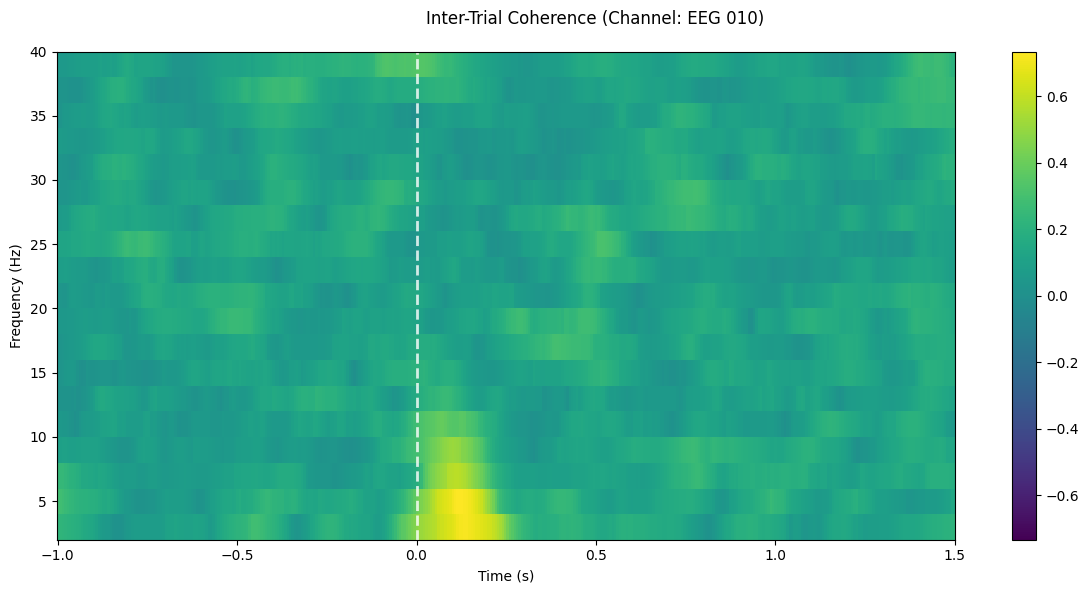


ITC解释:
  ITC = 0: 各trial相位完全随机
  ITC = 1: 各trial相位完全一致
  高ITC表明事件引发了相位重排


In [ ]:
# 可视化ITC
fig, ax = plt.subplots(figsize=(12, 6))
im = itc.plot(
    picks=[ch_idx],
    show=False,
    axes=ax,
    cmap='viridis',
    colorbar=True,
    title=f'Inter-Trial Coherence (Channel: {itc.ch_names[ch_idx]})'
)

# 绘图后修改色标上下限
# ax.images[0].set_clim(vmin=-1, vmax=1)

ax.axvline(x=0, color='white', linestyle='--', linewidth=2, alpha=0.8)
plt.tight_layout()
plt.show()

print("\nITC解释:")
print("  ITC = 0: 各trial相位完全随机")
print("  ITC = 1: 各trial相位完全一致")
print("  高ITC表明事件引发了相位重排")

### 7. 多锥度方法（Multitaper）对比

In [83]:
# 使用多锥度方法进行对比
# 多锥度方法在高频区域通常提供更好的频率分辨率

print("使用多锥度方法计算时频表示...")

# 多锥度方法适用于较高频率
freqs_mt = np.arange(10, 40, 2)  # 仅计算10-40 Hz

# 使用多锥度方法计算时频表示
power_mt = tfr_multitaper(
    epochs,                           # 输入的epochs数据
    freqs=freqs_mt,                   # 频率范围
    n_cycles=freqs_mt / 4.0,          # 每个频率的周期数
    use_fft=True,                     # 使用FFT加速计算
    return_itc=False,                 # 不返回ITC（相位锁定值）
    average=True,                     # 对所有epochs取平均,得到平均功率谱 (nch, n_freq, n_time)
    verbose=False                     # 不显示详细输出
)
print(power_mt.shape)
# 对多锥度方法的功率谱进行基线校正
power_mt.apply_baseline(baseline=(-0.5, -0.1), mode='logratio')
print("多锥度方法的功率谱基线校正完成!")


使用多锥度方法计算时频表示...
(59, 15, 376)
多锥度方法的功率谱基线校正完成!


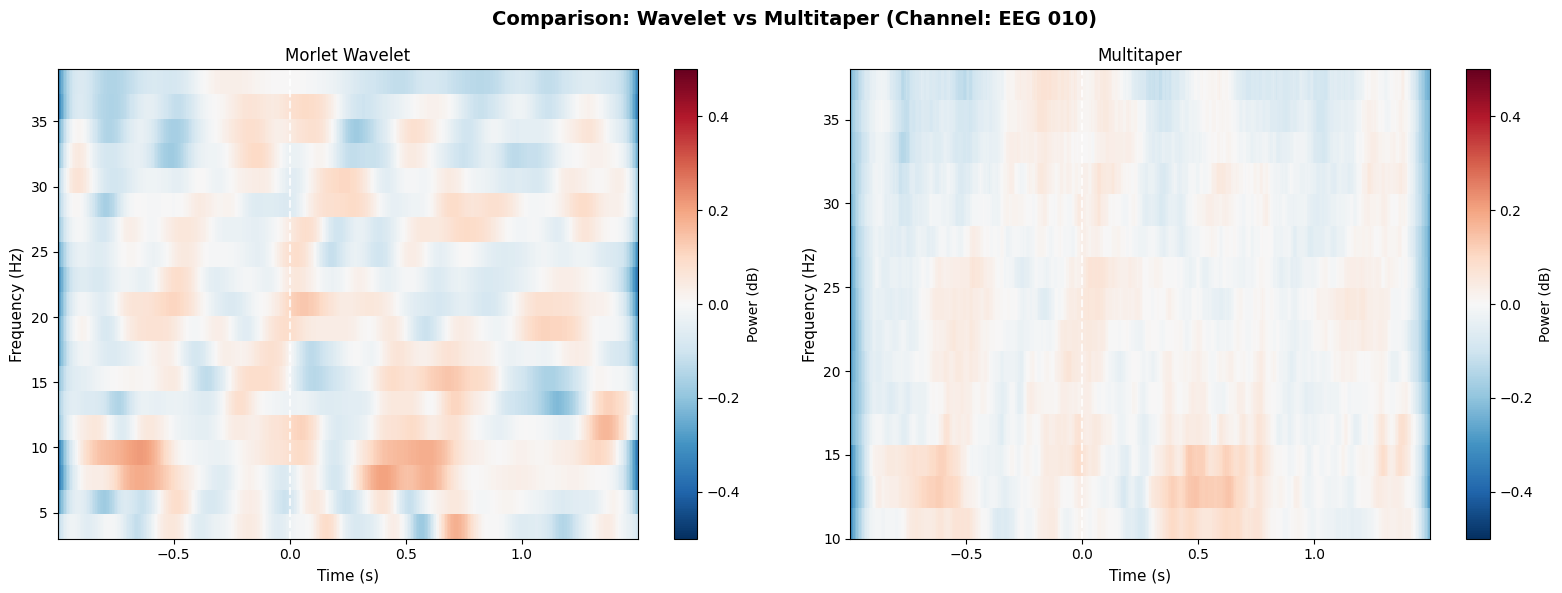


方法对比:
  Morlet小波: 适合全频段，时间-频率自适应
  多锥度: 适合高频，频率分辨率更好，减少频谱泄漏


In [95]:
# 对比小波和多锥度方法
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 小波方法
im1 = axes[0].imshow(
    power_avg.data[ch_idx],  # 取目标通道的功率谱(n_freq, n_time)
    aspect='auto',
    origin='lower',
    cmap='RdBu_r',
    vmin=-1.0,
    vmax=1.0,
    extent=[
        power.times[0], 
        power.times[-1], 
        freqs[0], 
        freqs[-1]
    ],
    interpolation='none'
)
im1.set_clim(-0.5, 0.5)
axes[0].set_title('Morlet Wavelet', fontsize=12)
axes[0].set_ylabel('Frequency (Hz)', fontsize=11)
axes[0].axvline(x=0, color='white', linestyle='--', linewidth=1.5, alpha=0.8)
plt.colorbar(im1, ax=axes[0], label='Power (dB)')

# 多锥度方法
im2 = axes[1].imshow(
    power_mt.data[ch_idx],  # 取目标通道的功率谱(n_freq, n_time)
    aspect='auto',
    origin='lower',
    cmap='RdBu_r',
    vmin=-1.0,
    vmax=1.0,
    extent=[
        power_mt.times[0],
        power_mt.times[-1],
        freqs_mt[0],
        freqs_mt[-1]
    ],
    interpolation='none'
)
axes[1].set_title('Multitaper', fontsize=12)
axes[1].set_ylabel('Frequency (Hz)', fontsize=11)
axes[1].axvline(x=0, color='white', linestyle='--', linewidth=1.5, alpha=0.8)
im2.set_clim(-0.5, 0.5)
plt.colorbar(im2, ax=axes[1], label='Power (dB)')



for ax in axes:
    ax.set_xlabel('Time (s)', fontsize=11)


# 调整子图间距
plt.subplots_adjust(wspace=0.3)

plt.suptitle(f'Comparison: Wavelet vs Multitaper (Channel: {power.ch_names[ch_idx]})',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n方法对比:")
print("  Morlet小波: 适合全频段，时间-频率自适应")
print("  多锥度: 适合高频，频率分辨率更好，减少频谱泄漏")

### 8. 地形图-时间分解（Time-Frequency Topomaps）

(59, 19, 376)


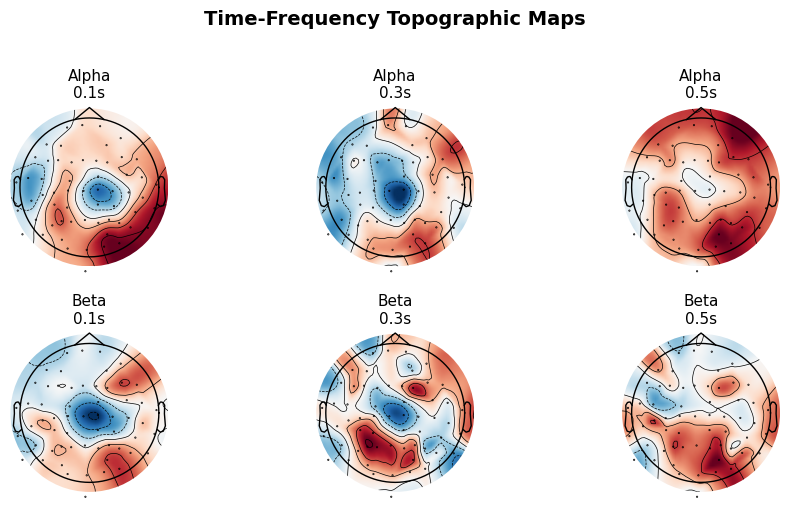

In [103]:
# 绘制特定时间和频段的头皮地形图
# 展示功率变化的空间分布

fig, axes = plt.subplots(2, 3, figsize=(10, 5))

# 定义时间和频段组合
time_freq_combos = [
    (0.1, (8, 13), 'Alpha\n0.1s'),
    (0.3, (8, 13), 'Alpha\n0.3s'),
    (0.5, (8, 13), 'Alpha\n0.5s'),
    (0.1, (13, 30), 'Beta\n0.1s'),
    (0.3, (13, 30), 'Beta\n0.3s'),
    (0.5, (13, 30), 'Beta\n0.5s'),
]

print(power_avg.data.shape) # (59, 19, 376)


for ax, (time, (fmin, fmax), title) in zip(axes.flat, time_freq_combos):
    # 提取特定时间和频段的数据
    t_idx = np.argmin(np.abs(power_avg.times - time)) # 找到最近的时间索引
    fmask = (freqs >= fmin) & (freqs <= fmax)
    
    # 计算该频段在该时刻的平均功率
    # power_avg.data[:, fmask, t_idx] 是 (n_channels, n_freqs) 形状的数组
    data = np.mean(power_avg.data[:, fmask, t_idx], axis=1) # 对频段取平均，得到 (n_channels,) 形状的数组
    
    # 创建临时的Evoked对象用于绘制地形图
    evoked_tmp = mne.EvokedArray(
        data[:, np.newaxis],  # 数据：将一维数组转换为二维数组 (n_channels, 1)，符合EvokedArray要求的形状
        power_avg.info,       # 信息对象：包含通道位置等元数据信息
        tmin=time,            # 起始时间：设置该地形图对应的时间点
        verbose=False         # 详细输出：关闭冗余信息输出
    )
    # 绘制地形图
    evoked_tmp.plot_topomap(
        times=[time],     # 时间点：指定要绘制的时间点
        axes=ax,          # 坐标轴：指定绘制的目标子图
        show=False,       # 显示：不立即显示图形，以便后续统一调整布局
        colorbar=False,   # 颜色条：不显示颜色条，保持子图简洁
        size=2            # 大小：设置地形图的大小
    )
    ax.set_title(title, fontsize=11)

plt.suptitle('Time-Frequency Topographic Maps', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### 9. 时频统计比较

In [154]:
# 比较两个条件的时频功率差异
# 使用聚类置换检验

print("加载视觉trial数据进行对比...")

# 重新创建包含两种条件的epochs
events_all = mne.find_events(raw, stim_channel='STI 014', verbose=False)
event_dict_all = {'auditory': 1, 'visual': 3} # 左耳1，做眼3
epochs_all = mne.Epochs(raw, events_all, event_id=event_dict_all,
                        tmin=-1, tmax=1,
                        baseline=None,
                        reject=dict(eeg=150e-6),
                        preload=True, verbose=False)



print(f"epochs_all形状: {epochs_all.get_data().shape}") # (145, 69, 301)
epochs_aud = epochs_all['auditory'].pick_types(eeg=True)
epochs_vis = epochs_all['visual'].pick_types(eeg=True)
print(f"epochs_aud形状: {epochs_aud.get_data().shape}") # (72, 59, 106)
print(f"epochs_vis形状: {epochs_vis.get_data().shape}") # (72, 59, 106) 



加载视觉trial数据进行对比...
epochs_all形状: (143, 69, 301)
epochs_aud形状: (72, 59, 301)
epochs_vis形状: (71, 59, 301)


In [156]:
# 计算时频功率（使用简化的频率范围）
freqs_simple = np.arange(5, 30, 5) # 5 10 15 20 25 30 Hz
n_cycles_simple = freqs_simple / 2.0 # 2.5 5.0 7.5 10.0 12.5 15.0 Hz

print(f"\n计算听觉时频功率...")
power_aud = tfr_morlet(
    epochs_aud,            # (72, 59, 106) (n_trials, n_channels, n_times)
    freqs=freqs_simple, 
    n_cycles=n_cycles_simple,
    use_fft=True, 
    return_itc=False, 
    average=True, 
    verbose=False
)# (59, 5, 301)(n_channels, n_freqs, n_times)
power_aud.apply_baseline(baseline=(-0.5, -0.1), mode='logratio')
print(f"power_aud形状: {power_aud.shape}") # (59, 5, 301)



计算听觉时频功率...
power_aud形状: (59, 5, 301)


In [157]:
print(f"计算视觉时频功率...")
power_vis = tfr_morlet(
    epochs_vis, 
    freqs=freqs_simple, 
    n_cycles=n_cycles_simple,
    use_fft=True, 
    return_itc=False, 
    average=True, 
    verbose=False
)
power_vis.apply_baseline(baseline=(-0.5, -0.1), mode='logratio')
print(f"power_vis形状: {power_vis.shape}") # (59, 5, 301)

print(f"计算听觉和视觉时频功率的差异...")
power_diff = power_aud.copy()
power_diff.data = power_aud.data - power_vis.data
print(f"power_diff形状: {power_diff.shape}") # (59, 5, 301)


计算视觉时频功率...
power_vis形状: (59, 5, 301)
计算听觉和视觉时频功率的差异...
power_diff形状: (59, 5, 301)


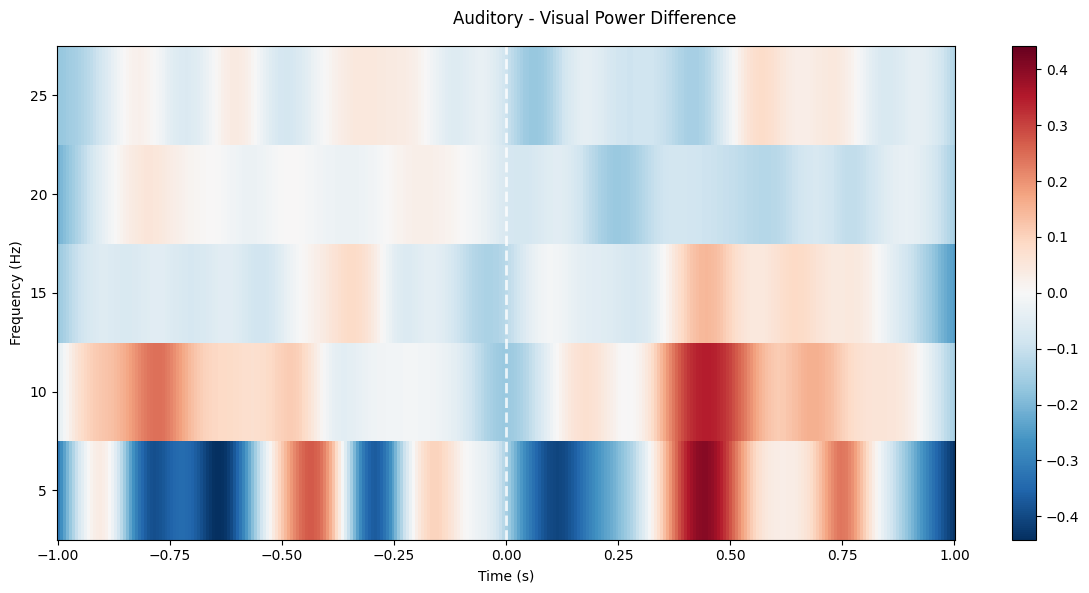


说明:
  红色 = 听觉功率 > 视觉功率
  蓝色 = 听觉功率 < 视觉功率
  (基于简化设置演示，完整分析需要更多trial和通道)


In [158]:
# 可视化差异
fig, ax = plt.subplots(figsize=(12, 6))
im = power_diff.plot(
    picks=[0],  # 只可视化第一个通道
    show=False, 
    axes=ax, 
    cmap='RdBu_r',
    colorbar=True,  
    title='Auditory - Visual Power Difference'
)
ax.axvline(x=0, color='white', linestyle='--', linewidth=2, alpha=0.8)
plt.tight_layout()
plt.show()

print("\n说明:")
print("  红色 = 听觉功率 > 视觉功率")
print("  蓝色 = 听觉功率 < 视觉功率")
print("  (基于简化设置演示，完整分析需要更多trial和通道)")

### 10. 时频分析总结与报告

In [166]:
# 生成时频分析报告

print("=" * 60)
print("时频分析 报告")
print("=" * 60)

print(f"\n【分析参数】")
print(f"- 方法: Morlet小波变换")
print(f"- 频率范围: {freqs[0]}-{freqs[-1]} Hz ({len(freqs)} 个频率点)")
print(f"- 小波周期数: {n_cycles[0]:.1f}-{n_cycles[-1]:.1f}")
print(f"- 基线窗口: -0.5 to -0.1 s")
print(f"- 基线校正: logratio (dB scale)")

print(f"\n【数据信息】")
print(f"- Trial数量: {len(epochs)}")
print(f"- 通道数: {len(epochs.ch_names)}")
print(f"- 时间窗口: [{epochs.tmin}, {epochs.tmax}] s")

print(f"\n【主要观察】")
for band_name, (fmin, fmax) in bands.items():
    fmask = (freqs >= fmin) & (freqs <= fmax)
    tmask_window = (power_avg.times >= 0) & (power_avg.times <= 0.5)
    band_ts = np.mean(power_avg.data[ch_idx, fmask, :], axis=0)
    mean_change = np.mean(band_ts[tmask_window])
    direction = "增加" if mean_change > 0 else "降低"
    print(f"- {band_name} ({fmin}-{fmax} Hz): 刺激后平均变化 {mean_change:+.3f} dB ({direction})")

print(f"\n【ITC观察】")
itc_max_val = np.max(itc.data[ch_idx])
itc_max_freq_idx = np.unravel_index(np.argmax(itc.data[ch_idx]), itc.data[ch_idx].shape)
itc_max_freq = freqs[itc_max_freq_idx[0]]
itc_max_time = itc.times[itc_max_freq_idx[1]]
print(f"- 最大ITC值: {itc_max_val:.3f}")
print(f"- 出现在: {itc_max_freq} Hz, {itc_max_time*1000:.0f} ms")

# 创建目录
outputs_dir = os.path.abspath("../outputs")
os.makedirs(outputs_dir, exist_ok=True)
# 保存时频数据
power_avg.save(os.path.join(outputs_dir, "tfr_power-tfr.hdf5"), overwrite=True)
print(f"\n时频功率数据已保存到: {os.path.join(outputs_dir, 'tfr_power-tfr.hdf5')}")




时频分析 报告

【分析参数】
- 方法: Morlet小波变换
- 频率范围: 3-39 Hz (19 个频率点)
- 小波周期数: 1.5-19.5
- 基线窗口: -0.5 to -0.1 s
- 基线校正: logratio (dB scale)

【数据信息】
- Trial数量: 71
- 通道数: 69
- 时间窗口: [-0.9989760657919393, 1.498464098687909] s

【主要观察】
- Theta (4-8 Hz): 刺激后平均变化 +0.020 dB (增加)
- Alpha (8-13 Hz): 刺激后平均变化 +0.019 dB (增加)
- Beta (13-30 Hz): 刺激后平均变化 -0.001 dB (降低)

【ITC观察】
- 最大ITC值: 0.734
- 出现在: 5 Hz, 120 ms

时频功率数据已保存到: d:\AI\trae_solo\Brain\ERP\outputs\tfr_power-tfr.hdf5


成功加载时频数据！
数据类型: <class 'mne.time_frequency.tfr.AverageTFR'>
数据形状: (59, 19, 376)


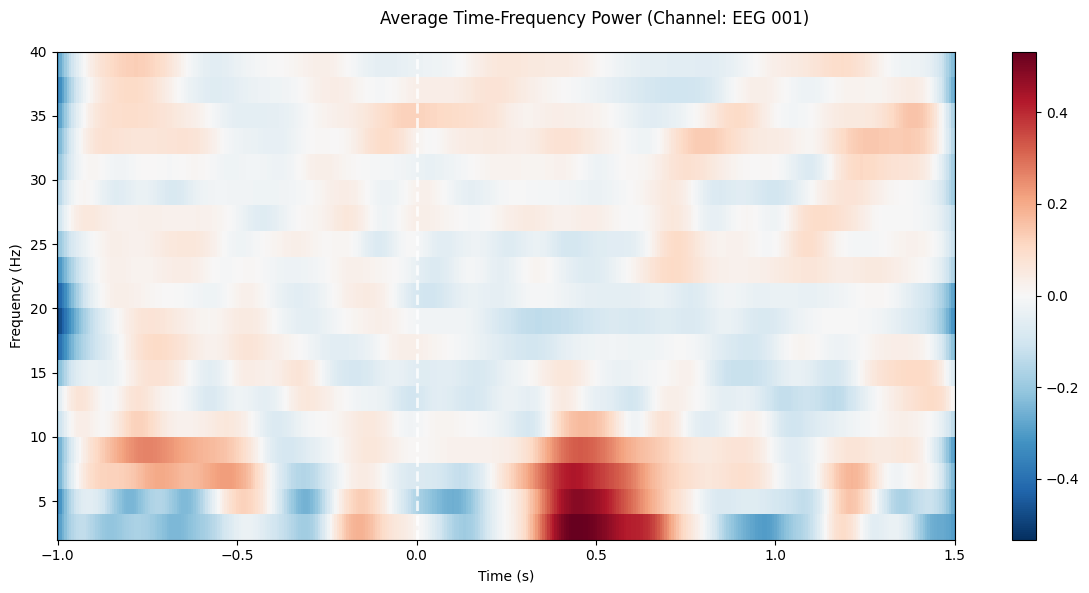

In [ ]:
# 从文件加载时频数据
# 创建目录
outputs_dir = os.path.abspath("../outputs")
os.makedirs(outputs_dir, exist_ok=True)
tfr_file_path = os.path.join(outputs_dir, "tfr_power-tfr.hdf5")


# read_tfrs 函数会返回一个列表，即使文件里只有一个 TFR 对象
power_avg_loaded = mne.time_frequency.read_tfrs(tfr_file_path)

# 4. (可选) 验证加载是否成功
print(f"成功加载时频数据！")
print(f"数据类型: {type(power_avg_loaded)}")
print(f"数据形状: {power_avg_loaded.data.shape}")
# 你可以尝试绘制一下，确认数据无误
fig, ax = plt.subplots(figsize=(12, 6))
ch_idx = 0
power_avg_loaded.plot(
    picks=[ch_idx], # (19,376)
    show=False,
    axes=ax,
    cmap='RdBu_r',
    colorbar=True,
    title=f'Average Time-Frequency Power (Channel: {power_avg.ch_names[ch_idx]})'
)
ax.axvline(x=0, color='white', linestyle='--', linewidth=2, alpha=0.8)
plt.tight_layout()
plt.show()

## 单元小结

**关键知识点回顾：**
1. **时频分析的意义**：捕获非相位锁定的神经振荡活动
2. **Morlet小波变换**：最常用方法，自适应时间-频率分辨率
3. **多锥度方法**：适合高频分析，减少频谱泄漏
4. **基线校正**：使用dB scale（logratio）计算ERS/ERD
5. **ITC分析**：评估事件引发的相位重排
6. **总功率分解**：Evoked Power（相位锁定）vs Induced Power（非相位锁定）

**分析要点：**
- 小波周期数影响时间-频率分辨率权衡
- 基线窗口应选择不包含实验相关活动的时期
- 多锥度方法在高频区域提供更好的频率分辨率

**下一步学习：**
- Unit 5将使用mne-sample-data完成从原始数据到ERP/时频分析的完整流程

**练习建议：**
1. 尝试不同的小波周期数，观察对时频图的影响
2. 比较不同基线校正方法（logratio, percent, zscore）的结果
3. 计算induced power（先计算每个trial的功率再平均）